In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

In [3]:
data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
S0 = np.where(brain_mask, S0, 0.)
x_o = data_norm[:, :, 28:29].squeeze()
S_o = S0[:, :, 28:29].squeeze()

/tmp/ipykernel_3421495/1639302203.py:12: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_3421495/1639302203.py:12: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


In [4]:
import numpy as np

import jax
import jax.numpy as jnp

from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx


In [11]:
from omegaconf import OmegaConf
res_folder = "/home/macke/mgloeckler90/dmri/results/dmri_ball_sticks_shared_param_real_new_no_bugs3"
config_path = res_folder + "/2025-04-14_19-02-52/0/.hydra/config.yaml"
cfg = OmegaConf.load(config_path)
print(cfg)

{'name': 'dmri_ball_sticks_shared_param_real_new_no_bugs3', 'seed': 0, 'use_wandb': True, 'wandb': {'project': 'dmri_ball_sticks_shared_param', 'entity': None}, 'simulator': {'sim_type': {'name': 'Ball3StickSharedDiffusivity'}, 'acquisition_scheme': {'name': 'hcp', 'params': {'num_acquisitions': 105}}, 'prior_mask_alpha': 1.0, 'prior_mask_beta': 1.0}, 'model': {'embedding_net': {'name': 'DMRIEmbeddingConfig', 'params': {'num_layers': 2, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'bvals_embed_dim': 12, 'signals_embed_dim': 12, 'bvec_repeats': 4, 'log_transform_signals': False}}, 'inference_net': {'name': 'DMRIThetaInferenceConfig', 'params': {'num_layers': 6, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'context_dim': 64, 'dropout_rate': None}}, 'model_selection_net': {'name': 'DMRIModelSelectionAmortizedPriorConfig', 'params': {'num_layers': 4, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'context_dim': 64, 'ma

In [12]:
from dmri.train.build_model import build_model
from dmri.train.build_simulator import build_simulator


sim_type, simulator = build_simulator(cfg)
model = build_model(cfg, sim_type)
model.eval()

graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)

In [13]:
 optimizer_cfg.scheduler

In [14]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [15]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [16]:
from dmri.train.checkpointing import CheckpointManager
checkpoint_dir = res_folder + "/checkpoints"
continue_training = True
checkpoint_manager = CheckpointManager(
        ckpt_dir=checkpoint_dir,
        max_to_keep=cfg.get("max_checkpoints", 3),
        keep_best=cfg.get("keep_best_checkpoint", True),
        recovery_threshold=cfg.get("recovery_threshold", float("inf")),
        continue_training=continue_training,
        use_async=cfg.get(
            "use_async_checkpointing", True
        ),  # Enable async checkpointing
    )

In [17]:
latest_step = checkpoint_manager.get_latest_step()
opt_state = optimizer.init(params)

In [18]:
checkpoint = checkpoint_manager.restore(
                step=latest_step, params=params, optimizer_state=opt_state,
            )

In [19]:
params = checkpoint["params"]

In [20]:
model = nnx.merge(graphdef, params, static, state)
model.eval()

In [21]:
nnx.display(model)

In [22]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

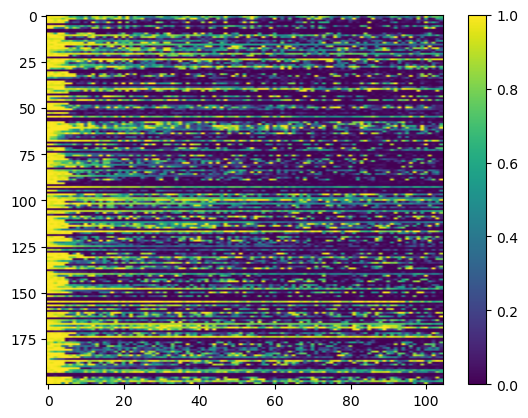

In [23]:
import matplotlib.pyplot as plt

p_mask,masks, theta, x_os, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [24]:
#idx = 2
idx = 15
masks[idx]

Array([False, False,  True,  True,  True], dtype=bool)

In [25]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.1]))

(0, 1, 2, 3, 4)


In [26]:
mask_true= masks[idx]

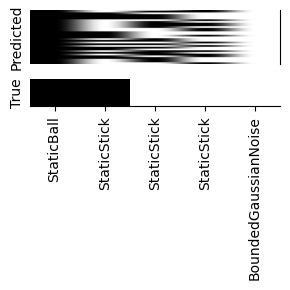

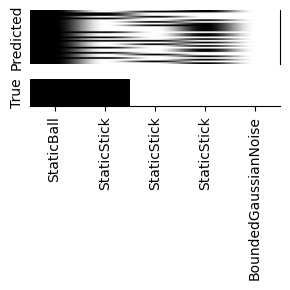

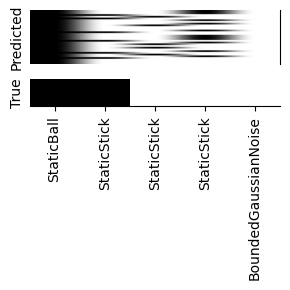

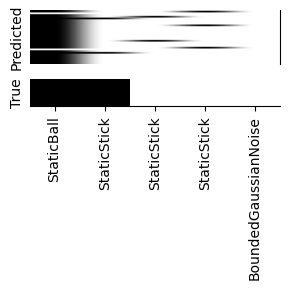

In [27]:
import matplotlib.pyplot as plt

for t in [0.01, 0.1, 0.5, 0.9]:
    mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 32), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([t]))
    fig = plt.figure(figsize=(3, 3))

    # Create a grid with 90% height for the predicted mask and 10% height for the true mask
    grid = plt.GridSpec(2, 1, height_ratios=[4, 2])

    # Plot predicted mask on top subplot
    ax1 = plt.subplot(grid[0])
    ax1.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax1.set_ylabel('Predicted')
    ax1.set_xticks([])  # Hide x-ticks
    ax1.set_yticks([])  # Hide y-ticks
    # Remove unnecessary spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)

    # Plot true mask on bottom subplot
    ax2 = plt.subplot(grid[1])
    ax2.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax2.set_ylabel('True')
    #ax2.set_xlabel('Model Type')

    # Set x-tick labels
    model_labels = [str(m).split(".")[-1].split("'")[0] for m in sim_type.model_types] + [str(m).split(".")[-1].split("'")[0] for m in sim_type.noise_types]
    ax2.set_xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)))
    ax2.set_xticklabels(model_labels, rotation=90)

    # Remove y-axis ticks
    ax2.set_yticks([])
    # Remove unnecessary spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.svg")
    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.png")

In [28]:
from functools import partial

thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


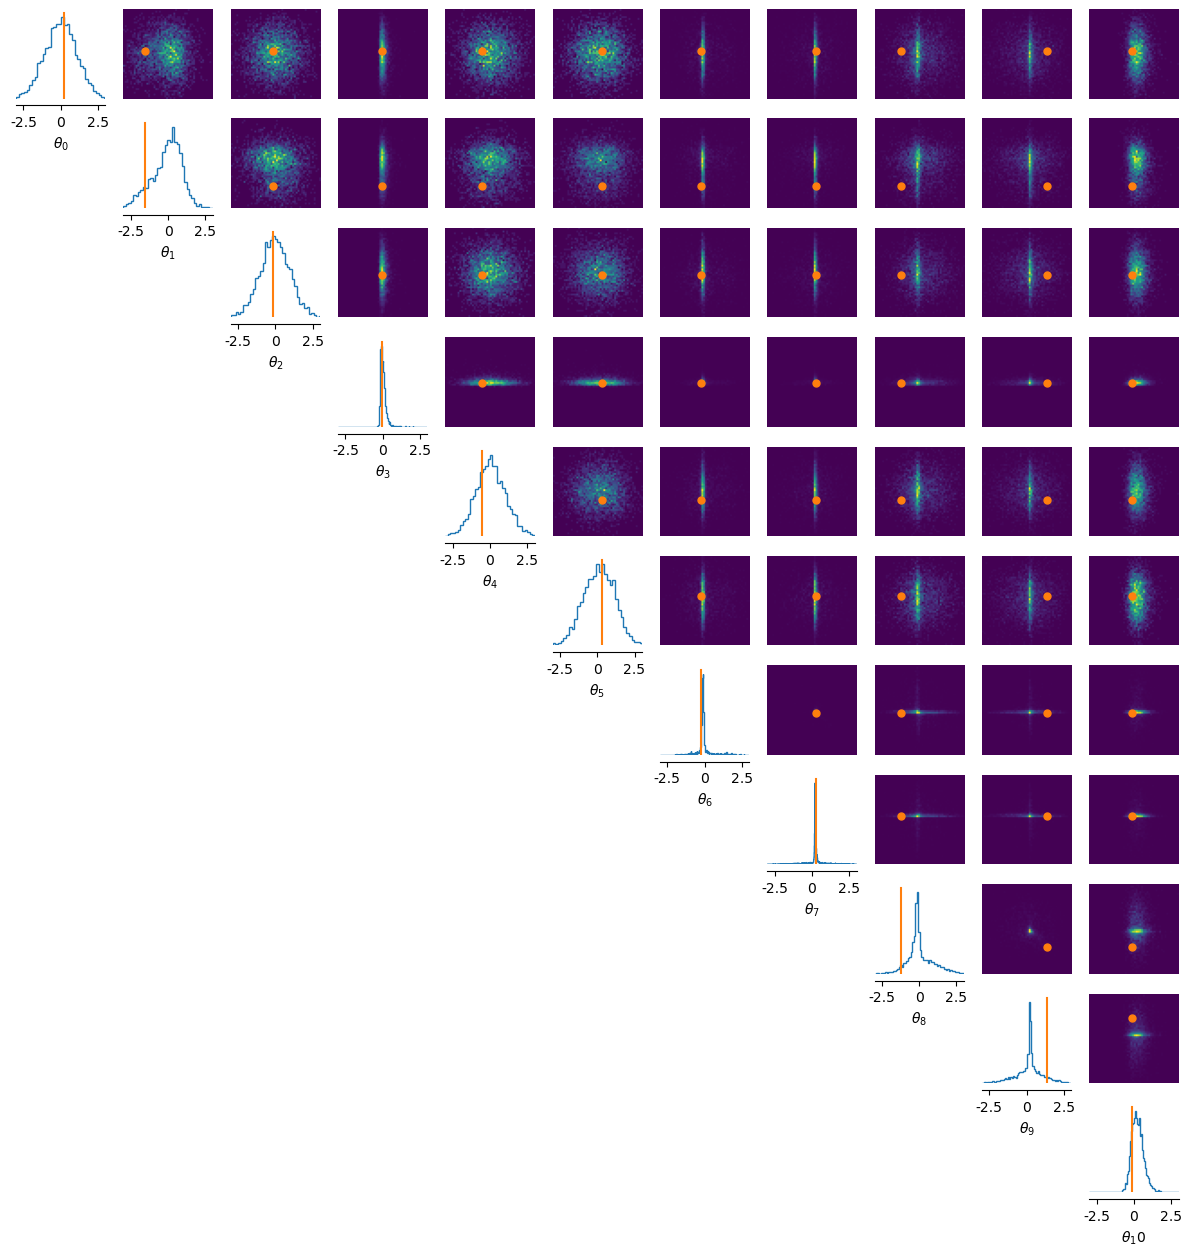

In [31]:
import sbi
from sbi.analysis.plot import pairplot

fig,axes = pairplot(thetas_post, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(15, 15))
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.svg")
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.png")

In [32]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [33]:
ll = loglikelihood(theta[idx])

Text(0, 0.5, 'MRI Signal')

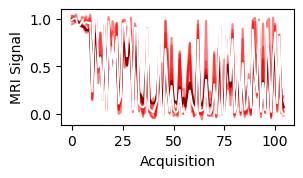

In [34]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(3, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [35]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=80, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [36]:
effectve_sample_size(thetas_post)

(0, 1, 2, 3, 4)


Array(1.057, dtype=float32)

In [37]:
score_theta = jax.vmap(model.score_theta)(theta,acq.bvals, acq.bvecs, x_os, masks)

(0, 1, 2, 3, 4)


In [38]:
jax.vmap(true_score)(theta, masks, acq, x_os)

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
This BatchTracer with object id 23416897041280 was created on line:
  /weka/macke/mgloeckler90/dmri/dmri/simulators/multi_compartment.py:242:20 (MultiCompartment.to_params)
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerBoolConversionError

In [40]:
score_theta

Array([[  40.412,  143.617,  -20.862, ..., -194.192,   84.162, -422.835],
       [-348.687, -370.204,  -12.666, ..., -225.171,  -23.544,   -6.08 ],
       [ -81.122,  -36.359,   54.717, ..., -141.144, -179.768,   91.791],
       ...,
       [-879.765,  529.766,   18.358, ..., -222.802,   53.883,  -13.635],
       [-257.552,  550.985,  -23.782, ..., -101.402,  104.308,  172.824],
       [ -44.465,  296.712,   20.355, ..., -222.206,   21.696, -419.796]],      dtype=float32)

In [41]:
effectve_sample_size(thetas_post)

Array(1.057, dtype=float32)

In [42]:
idx = np.argsort(bvals)
bvals = bvals[idx]
bvecs = bvecs[idx]
x_o = x_o[...,idx]
data_norm = data_norm[...,idx]


In [43]:
np.quantile(x_o, [0.01, 0.999])

array([-0.024,  1.027])

In [44]:
x_o = jnp.clip(x_o, None, 1.4)

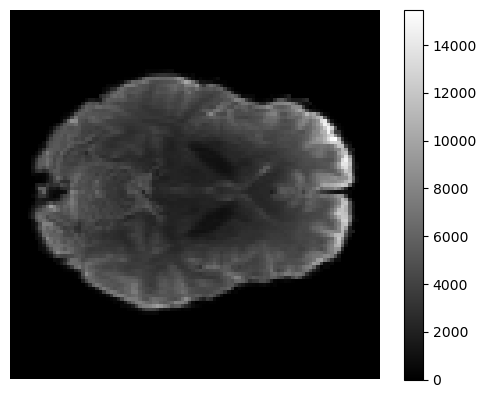

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
l = ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
plt.colorbar(l)
#ax.set_title('HCP coronal slice B0 with ROI')

In [36]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

In [37]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

In [38]:
data.shape

(104, 104, 72, 105)

In [39]:
full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [40]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])
brain_mask_slice = brain_mask[:,:,28:29].squeeze()
brain_mask_slice_flat = brain_mask_slice.reshape(-1)

In [41]:
x_o_flat[5000]

Array([ 0.99 ,  1.006,  1.013,  0.961,  0.976,  1.027,  0.221,  0.1  ,
        0.62 ,  0.016,  0.102,  0.248,  0.06 ,  0.994,  0.91 ,  0.905,
        0.584,  0.011,  0.579,  0.666,  0.157,  0.02 ,  0.099,  0.198,
        0.029,  0.008,  0.488,  0.201,  0.089,  0.839,  0.846, -0.011,
        0.052,  0.843,  0.705,  0.866,  0.862,  0.015,  0.131,  0.29 ,
        0.047,  0.497,  0.551,  0.076,  0.144,  0.817,  0.274,  0.078,
        0.875,  0.036,  0.267,  0.881,  0.033,  0.55 ,  0.047,  0.003,
       -0.009,  0.799,  0.723,  0.019,  1.001,  0.971,  0.005,  0.138,
        0.021,  0.9  ,  0.036,  0.922,  0.03 ,  0.945,  0.5  ,  0.248,
        0.033,  0.553,  0.173, -0.002,  0.96 ,  0.122,  0.009,  0.972,
       -0.004,  0.845,  0.073,  0.046,  0.005,  0.042,  0.924, -0.013,
        0.035, -0.016, -0.032,  0.942,  0.715,  0.842,  0.165,  0.087,
        0.898,  0.007,  0.078, -0.021,  0.482,  0.873,  0.011,  0.125,
        0.027], dtype=float32)

In [42]:
model_mask = jnp.array([True, True, True, True, True, False, False], dtype=jnp.bool)

In [47]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    return loglikelihood(theta, mask, acq, x) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

@jax.jit
def importance_resample(key,x, K=20):
    key, subkey = jax.random.split(key)
    key_propose = jax.random.split(subkey, K)
    samples, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=32, max_noise=40), in_axes=(0,None,None, None, None))(key_propose, acq.bvals, acq.bvecs, x,model_mask)
    log_probs_posterior = jax.vmap(log_posterior, in_axes=(0,None,None,None))(samples, model_mask, acq, x)
    weights = log_probs_posterior - log_probs
    weights = jax.nn.softmax(weights)
    weights = jnp.nan_to_num(weights, 0)
    sample = jax.random.choice(subkey, samples, p=weights)
    ess = 1/jnp.sum(weights**2)
    ess = jnp.nan_to_num(ess, 0, posinf=0,neginf=0)
    return sample, ess
sample_theta_per_x =jax.jit(jax.vmap(importance_resample))

In [44]:
sample_theta_per_x

<PjitFunction of <function importance_resample at 0x15411a7dc540>>

In [45]:
print("Hey")

Hey


In [77]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 20_000
key = jax.random.key(0)
for i in range(10):
    thetas_full = []
    key, subkey = jax.random.split(key)
    for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
        subkey, subkey_ = jax.random.split(subkey)
        batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
        batch_data = full_data_flat_in_brain[batch_start:batch_end]
        batch_keys = jax.random.split(subkey_, batch_data.shape[0])
        #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
        batch_thetas = sample_theta_per_x(batch_keys, batch_data)
        batch_thetas = np.array(batch_thetas)
        thetas_full.append(batch_thetas)
        #print(ess.mean())
    thetas_full = np.concatenate(thetas_full, axis=0)

    thetas.append(thetas_full)


(0, 1, 2, 3, 4)
(0, 1, 2, 3, 4)


In [70]:
len(thetas),len(thetas_full)

(1, 227840)

In [444]:
# Convert list of arrays to a single array first
thetas_array = np.array(thetas)
np.save("thetas.npy", thetas_array)

In [92]:
thetas_old = np.load("thetas.npy")

In [109]:
thetas = []
for i in range(50):
    try:
        theta_i = np.load(f"thetas_{i}.npy")
        theta_i[np.isnan(theta_i)] = thetas_old[i][np.isnan(theta_i)]
        theta_i[np.isnan(theta_i)] = np.random.randn(*theta_i[np.isnan(theta_i)].shape)
        thetas.append(theta_i)
    except:
        print(f"thetas_{i}.npy does not exist")


In [78]:
def to_fractions(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_fractions

def to_diffusivities(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[0].lam

def direction_s1(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[1].mu

def direction_s2(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[2].mu

def direction_s3(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[3].mu

fractions = []
for theta in thetas:
    fractions += [jax.vmap(to_fractions)(theta)]

diffusivities = []
for theta in thetas:
    diffusivities += [jax.vmap(to_diffusivities)(theta)]

mu_s1 = []
for theta in thetas:
    mu_s1 += [jax.vmap(direction_s1)(theta)]

mu_s2 = []
for theta in thetas:
    mu_s2 += [jax.vmap(direction_s2)(theta)]

mu_s3 = []
for theta in thetas:
    mu_s3 += [jax.vmap(direction_s3)(theta)]

fractions = np.array(fractions)
fractions_mean = fractions.mean(axis=0)
fractions_std = fractions.std(axis=0)


In [79]:
diffusivities = np.array(diffusivities)
diffusivities_mean = diffusivities.mean(axis=0)
diffusivities_std = diffusivities.std(axis=0)


In [80]:
full_data_flat_in_brain.shape

(227840, 105)

In [81]:
fractions_mean.shape

(227840, 4)

In [82]:
fractions_mean.shape

(227840, 4)

In [83]:
full_fractions_mean = np.zeros(full_data_flat.shape[:-1] + (4,))
full_fractions_std = np.zeros(full_data_flat.shape[:-1] + (4,))
full_fractions_mean[brain_mask_flat.astype(np.bool),:] = fractions_mean
full_fractions_std[brain_mask_flat.astype(np.bool),:] = fractions_std
full_fractions_mean = full_fractions_mean.reshape(data_norm.shape[:-1] + (4,))
full_fractions_std = full_fractions_std.reshape(data_norm.shape[:-1] + (4,))


In [84]:
full_diffusivities_mean = np.zeros(full_data_flat.shape[:-1] + (1,))
full_diffusivities_std = np.zeros(full_data_flat.shape[:-1] + (1,))
full_diffusivities_mean[brain_mask_flat.astype(np.bool),:] = diffusivities_mean[...,None]
full_diffusivities_std[brain_mask_flat.astype(np.bool),:] = diffusivities_std[...,None]
full_diffusivities_mean = full_diffusivities_mean.reshape(data_norm.shape[:-1] + (1,))
full_diffusivities_std = full_diffusivities_std.reshape(data_norm.shape[:-1] + (1,))


In [85]:
full_fractions_mean.shape

(104, 104, 72, 4)

In [86]:
mu_s1 = np.array(mu_s1)
mu_s2 = np.array(mu_s2)
mu_s3 = np.array(mu_s3)


(10, 227840, 2)

In [100]:
import numpy as np
from sklearn.decomposition import PCA


def sph2cart(angles):
    theta, phi = angles[:, 0], angles[:, 1]
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.stack([x, y, z], axis=-1)

def reorder_angles_for_consistency(angles1, angles2, angles3, n_references=2):
    """
    Reorder fiber directions across the batch so that similar directions are consistently aligned
    for meaningful averaging using PCA to determine multiple global reference directions.

    Args:
        angles1: [N, 2] array of [theta, phi] directions
        angles2: [N, 2] array of [theta, phi] directions
        angles3: [N, 2] array of [theta, phi] directions
        n_references: Number of PCA components to use as global references

    Returns:
        reordered_angles1: [N, 2] aligned to the dominant global direction(s)
        reordered_angles2: [N, 2] second-best aligned direction(s)
        reordered_angles3: [N, 2] least aligned direction(s)
    """


    v1 = sph2cart(angles1)
    v2 = sph2cart(angles2)
    v3 = sph2cart(angles3)

    # Convert nan to random vector


    # === Step 1: Use PCA of all vectors to get global references ===
    all_vectors = np.vstack([v1, v2, v3])
    # Covert nan to 0
    all_vectors[np.isnan(all_vectors)] = np.random.randn(*all_vectors[np.isnan(all_vectors)].shape)*0.01
    pca = PCA(n_components=n_references)
    pca.fit(all_vectors)
    global_refs = pca.components_

    # === Step 2: Compute maximum alignment of each vector to global references ===
    def max_dot(vectors):
        dots = vectors @ global_refs.T
        return np.max(dots, axis=1)

    dot1 = max_dot(v1)
    dot2 = max_dot(v2)
    dot3 = max_dot(v3)

    # Stack dots and angles for sorting
    dots = np.stack([dot1, dot2, dot3], axis=1)
    angles_stacked = np.stack([angles1, angles2, angles3], axis=1)

    # === Step 3: Sort angles based on alignment ===
    sorted_indices = np.argsort(-dots, axis=1)

    reordered_angles1 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 0], :]
    reordered_angles2 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 1], :]
    reordered_angles3 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 2], :]

    return reordered_angles1, reordered_angles2, reordered_angles3

# Example loop for reordering angles for all samples
mu_s1_reordered, mu_s2_reordered, mu_s3_reordered = [], [], []
for i in range(mu_s1.shape[1]):
    angles1, angles2, angles3 = reorder_angles_for_consistency(
        mu_s1[:, i], mu_s2[:, i], mu_s3[:, i])
    mu_s1_reordered.append(angles1)
    mu_s2_reordered.append(angles2)
    mu_s3_reordered.append(angles3)

mu_s1_reordered = np.stack(mu_s1_reordered, axis=1)
mu_s2_reordered = np.stack(mu_s2_reordered, axis=1)
mu_s3_reordered = np.stack(mu_s3_reordered, axis=1)


In [101]:
mu_s1.shape

(10, 227840, 2)

In [102]:
# Samples by angle

mu_s1_theta = mu_s1_reordered[:,:,0].T
mu_s1_phi = mu_s1_reordered[:,:,1].T
mu_s2_theta = mu_s2_reordered[:,:,0].T
mu_s2_phi = mu_s2_reordered[:,:,1].T
mu_s3_theta = mu_s3_reordered[:,:,0].T
mu_s3_phi = mu_s3_reordered[:,:,1].T


In [103]:
from dmri.utils.dmriutils import make_dyads
from functools import partial

In [104]:
s1_dyads_mean = jax.vmap(partial(make_dyads))(mu_s1_theta, mu_s1_phi)[0]
s1_dyads_disp = jax.vmap(partial(make_dyads))(mu_s1_theta, mu_s1_phi)[1]
s2_dyads_mean = jax.vmap(partial(make_dyads))(mu_s2_theta, mu_s2_phi)[0]
s2_dyads_disp = jax.vmap(partial(make_dyads))(mu_s2_theta, mu_s2_phi)[1]
s3_dyads_mean = jax.vmap(partial(make_dyads))(mu_s3_theta, mu_s3_phi)[0]
s3_dyads_disp = jax.vmap(partial(make_dyads))(mu_s3_theta, mu_s3_phi)[1]


(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)


In [106]:
full_s1_theta_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s1_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s1_theta
full_s1_theta_samples = full_s1_theta_samples.reshape(data_norm.shape[:-1] + (50,))

full_s1_phi_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s1_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s1_phi
full_s1_phi_samples = full_s1_phi_samples.reshape(data_norm.shape[:-1] + (50,))

full_s2_theta_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s2_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s2_theta
full_s2_theta_samples = full_s2_theta_samples.reshape(data_norm.shape[:-1] + (50,))

full_s2_phi_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s2_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s2_phi
full_s2_phi_samples = full_s2_phi_samples.reshape(data_norm.shape[:-1] + (50,))

full_s3_theta_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s3_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s3_theta
full_s3_theta_samples = full_s3_theta_samples.reshape(data_norm.shape[:-1] + (50,))

full_s3_phi_samples = np.zeros(full_data_flat.shape[:-1] + (50,))
full_s3_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s3_phi
full_s3_phi_samples = full_s3_phi_samples.reshape(data_norm.shape[:-1] + (50,))


ValueError: shape mismatch: value array of shape (227840,10) could not be broadcast to indexing result of shape (227840,50)

In [176]:
import nibabel as nib
from dmri.utils.dmriutils import export_nifti
org_data = nib.load("data/data.nii.gz")

export_nifti(full_s1_theta_samples, org_data, "", "ball3stick_low_var_results/s1_theta_samples.nii.gz")
export_nifti(full_s1_phi_samples, org_data, "", "ball3stick_low_var_results/s1_phi_samples.nii.gz")
export_nifti(full_s2_theta_samples, org_data, "", "ball3stick_low_var_results/s2_theta_samples.nii.gz")
export_nifti(full_s2_phi_samples, org_data, "", "ball3stick_low_var_results/s2_phi_samples.nii.gz")
export_nifti(full_s3_theta_samples, org_data, "", "ball3stick_low_var_results/s3_theta_samples.nii.gz")
export_nifti(full_s3_phi_samples, org_data, "", "ball3stick_low_var_results/s3_phi_samples.nii.gz")


In [107]:
full_s1_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s1_dyads_mean[brain_mask_flat.astype(np.bool),:] = s1_dyads_mean
full_s1_dyads_mean = full_s1_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s1_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s1_dyads_disp[brain_mask_flat.astype(np.bool),:] = s1_dyads_disp[...,None]
full_s1_dyads_disp = full_s1_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

# export_nifti(full_s1_dyads_mean, org_data, "", "ball3stick_low_var_results/s1_dyads_mean.nii.gz")
# export_nifti(full_s1_dyads_disp, org_data, "", "ball3stick_low_var_results/s1_dyads_disp.nii.gz")


In [108]:
full_s2_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s2_dyads_mean[brain_mask_flat.astype(np.bool),:] = s2_dyads_mean
full_s2_dyads_mean = full_s2_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s2_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s2_dyads_disp[brain_mask_flat.astype(np.bool),:] = s2_dyads_disp[...,None]
full_s2_dyads_disp = full_s2_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

# export_nifti(full_s2_dyads_mean, org_data, "", "ball3stick_low_var_results/s2_dyads_mean.nii.gz")
# export_nifti(full_s2_dyads_disp, org_data, "", "ball3stick_low_var_results/s2_dyads_disp.nii.gz")


In [109]:
full_s3_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s3_dyads_mean[brain_mask_flat.astype(np.bool),:] = s3_dyads_mean
full_s3_dyads_mean = full_s3_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s3_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s3_dyads_disp[brain_mask_flat.astype(np.bool),:] = s3_dyads_disp[...,None]
full_s3_dyads_disp = full_s3_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

# export_nifti(full_s3_dyads_mean, org_data, "", "ball3stick_low_var_results/s3_dyads_mean.nii.gz")
# export_nifti(full_s3_dyads_disp, org_data, "", "ball3stick_low_var_results/s3_dyads_disp.nii.gz")


(np.float64(-0.5), np.float64(103.5), np.float64(103.5), np.float64(-0.5))

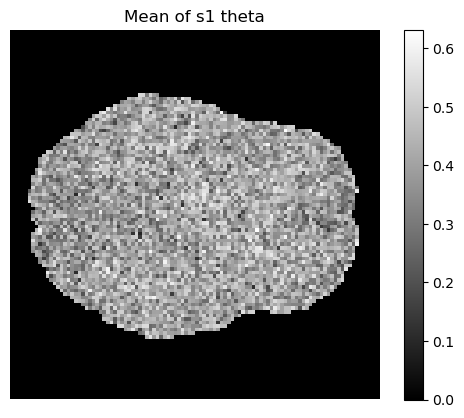

In [112]:
plt.imshow(full_s2_dyads_disp[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.title("Mean of s1 theta")
plt.axis("off")

In [194]:
full_f1_mean = full_fractions_mean[...,0]
full_f1_std = full_fractions_std[...,0]
full_f2_mean = full_fractions_mean[...,1]
full_f2_std = full_fractions_std[...,1]
full_f3_mean = full_fractions_mean[...,2]
full_f3_std = full_fractions_std[...,2]
full_f4_mean = full_fractions_mean[...,3]
full_f4_std = full_fractions_std[...,3]
full_diff_mean = full_diffusivities_mean[...,0]
full_diff_std = full_diffusivities_std[...,0]


In [195]:
from dmri.utils.dmriutils import export_nifti
import nibabel as nib
org_data = nib.load("data/data.nii.gz")
export_nifti(full_f1_mean, org_data, "", "ball3stick_low_var_results/f0_fraction_mean.nii.gz")
export_nifti(full_f1_std, org_data, "", "ball3stick_low_var_results/f0_fraction_std.nii.gz")
export_nifti(full_f2_mean, org_data, "", "ball3stick_low_var_results/f1_fraction_mean.nii.gz")
export_nifti(full_f2_std, org_data, "", "ball3stick_low_var_results/f1_fraction_std.nii.gz")
export_nifti(full_f3_mean, org_data, "", "ball3stick_low_var_results/f2_fraction_mean.nii.gz")
export_nifti(full_f3_std, org_data, "", "ball3stick_low_var_results/f2_fraction_std.nii.gz")
export_nifti(full_f4_mean, org_data, "", "ball3stick_low_var_results/f3_fraction_mean.nii.gz")
export_nifti(full_f4_std, org_data, "", "ball3stick_low_var_results/f3_fraction_std.nii.gz")
export_nifti(full_diff_mean, org_data, "", "ball3stick_low_var_results/diff_mean.nii.gz")
export_nifti(full_diff_std, org_data, "", "ball3stick_low_var_results/diff_std.nii.gz")

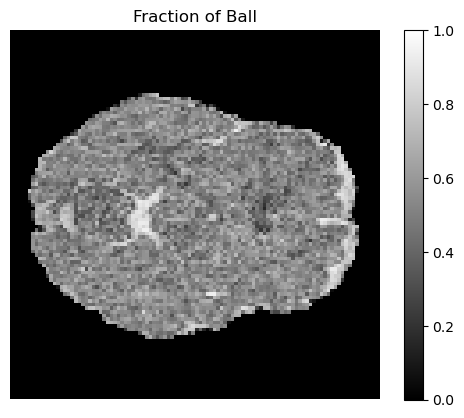

In [96]:
plt.imshow(brain_mask_slice * full_fractions_mean[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Fraction of Ball")
plt.colorbar()


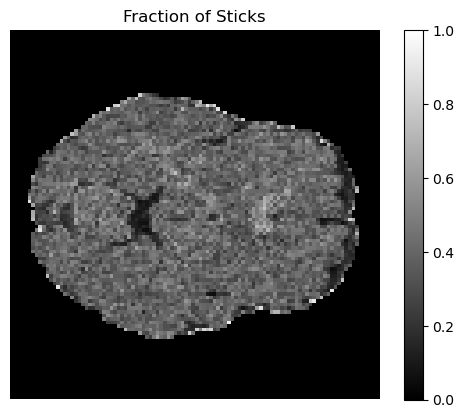

In [98]:
plt.imshow(brain_mask_slice * full_fractions_mean[...,28:29,1:3].sum(axis=-1).reshape(x_o.shape[:-1]), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Fraction of Sticks")
plt.colorbar()

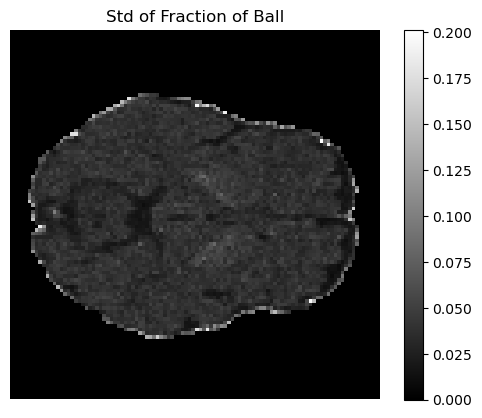

In [200]:
plt.imshow(brain_mask_slice * full_fractions_std[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.axis("off")
plt.title("Std of Fraction of Ball")
plt.colorbar()

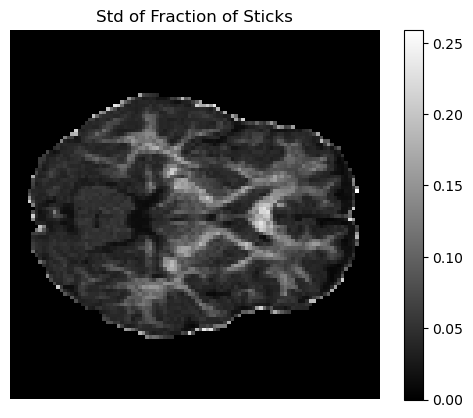

In [201]:
plt.imshow(brain_mask_slice * full_fractions_std[...,28:29,1:3].mean(axis=-1).reshape(x_o.shape[:-1]), cmap="gray")
plt.axis("off")
plt.title("Std of Fraction of Sticks")
plt.colorbar()

Text(0.5, 1.0, 'Mean of Diffusivity')

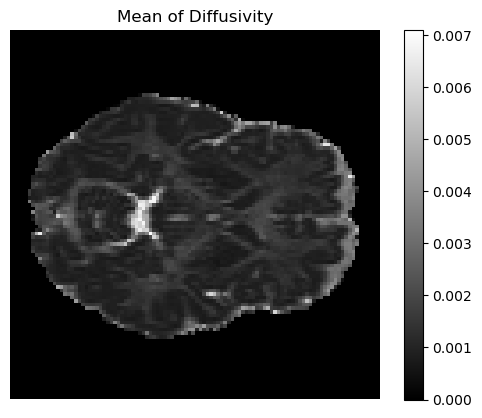

In [46]:
plt.imshow(brain_mask_slice * full_diffusivities_mean[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.axis("off")
plt.title("Mean of Diffusivity")

Text(0.5, 1.0, 'Std of Diffusivity')

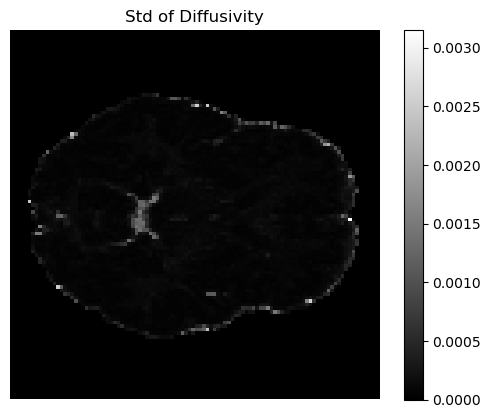

In [47]:
plt.imshow(brain_mask_slice * full_diffusivities_std[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.axis("off")
plt.title("Std of Diffusivity")


In [479]:
x_o_flat.shape

(10816, 105)

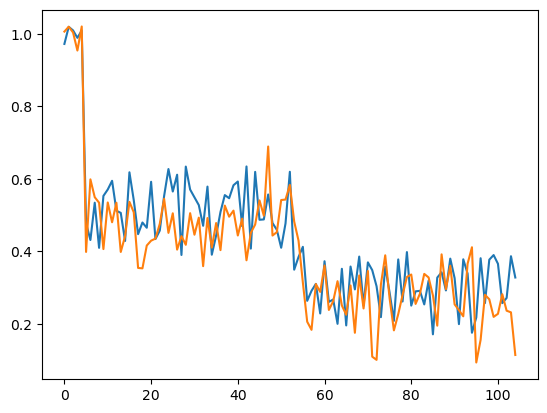

In [315]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[1])
i = 4005
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")